In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [13]:
COLORS = {
    "STARBUCKS_GREEN": "#00704A",
    "COFFEE": "#4D2F1F",
    "MINT": "#D3F2E8",
    "O_ACCENT": "#FF8445",
    "Y_ACCENT": "#FCC756",
    "BEIGE": "#c9bd9f",
    "ROSE": "#f55b6f",
    "GREEN2": "#00D18B",
    "DARK_ROSE": "#f75267"
}

acsent_palette = [
    COLORS["ROSE"],
    COLORS["STARBUCKS_GREEN"],
    COLORS["Y_ACCENT"],
    COLORS["O_ACCENT"]
]

starbucks_palette = [
    COLORS["COFFEE"],
    COLORS["STARBUCKS_GREEN"],
    COLORS["GREEN2"],
    COLORS["Y_ACCENT"],
    COLORS["O_ACCENT"],
    COLORS["DARK_ROSE"],
    COLORS["MINT"],
    COLORS["BEIGE"]
]

SEGMENT_COLORS = {
    "Fast & Standard": COLORS["MINT"],
    "Patient & Standard": COLORS["BEIGE"],
    "Dissatisfied": COLORS["O_ACCENT"],
    "Bulk Buyers": COLORS["COFFEE"],
    "Customization Kings": COLORS["STARBUCKS_GREEN"]
}

STARBUCKS_CMAP = LinearSegmentedColormap.from_list(
    "Starbucks", 
    [COLORS["COFFEE"], "#f2f0df", COLORS["STARBUCKS_GREEN"]]
)

sns.set_palette(starbucks_palette)
sns.set_theme(style="whitegrid")



In [14]:
df = pd.read_csv("starbucks_customer_ordering_patterns.csv", index_col="order_id")
df.head()


,customer_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
order_id,,,,,,,,,,,,,,,,,,,
ORD_00000001,CUST_12974,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
ORD_00000002,CUST_08235,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
ORD_00000003,CUST_00393,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
ORD_00000004,CUST_06936,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
ORD_00000005,CUST_09800,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [15]:
numerical_fields = ["cart_size", "num_customizations", "total_spend", "fulfillment_time_min", "customer_satisfaction"]
stats_df = df[numerical_fields].agg(["mean", "median", "std"]
)
stats_df


,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
mean,3.741495,1.810754,14.866723,4.546079,3.687536
median,4.000000,2.000000,14.170000,4.400000,4.000000
std,1.697803,1.462790,5.506755,1.550254,1.184112


In [16]:
nan_rows = df[df.isna().any(axis=1)]

print(f"Number of rows with missing values (NaN): {len(nan_rows)}")
if len(nan_rows) > 0:
    print("Rows containing missing values (to be removed):")
    display(nan_rows)
else:
    print("No missing values (NaN) found. The data is clean!")

duplicates = df.duplicated().sum()
print("Number of duplicate rows: ", duplicates)


Number of rows with missing values (NaN): 0
No missing values (NaN) found. The data is clean!
Number of duplicate rows:  0


In [17]:
print("Column data types:")
print(df.dtypes)


Column data types:
customer_id               object
order_date                object
order_time                object
day_of_week               object
order_channel             object
store_id                  object
store_location_type       object
region                    object
customer_age_group        object
customer_gender           object
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category            object
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64
dtype: object


Total Spending Distribution with respect to Rewards Program

/var/folders/vf/__4sd2yj09b6xhtcxvwtxcc40000gn/T/ipykernel_3539/4257982304.py:2: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.histplot(data=df, x="total_spend", hue="is_rewards_member", kde=True, palette=acsent_palette, multiple="stack")


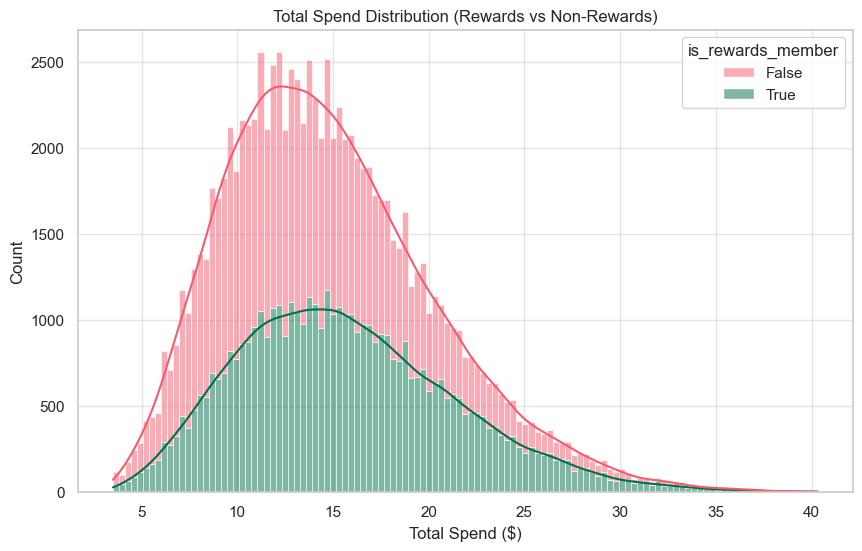

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="total_spend", hue="is_rewards_member", kde=True, palette=acsent_palette, multiple="stack")
plt.title("Total Spend Distribution (Rewards vs Non-Rewards)")
plt.xlabel("Total Spend ($)")
plt.show()


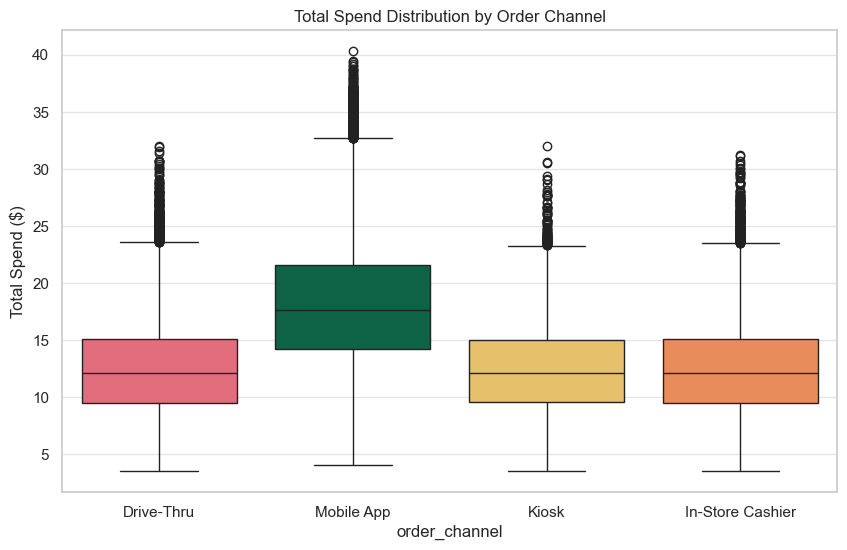

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="order_channel", y="total_spend", hue="order_channel", palette=acsent_palette, legend=False)
plt.title("Total Spend Distribution by Order Channel")
plt.ylabel("Total Spend ($)")
plt.show()


/var/folders/vf/__4sd2yj09b6xhtcxvwtxcc40000gn/T/ipykernel_3539/761407995.py:7: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.lineplot(data=fulfillment_trends, x="day_of_week", y="fulfillment_time_min", hue="order_channel", marker="o", palette=starbucks_palette, sort=False)


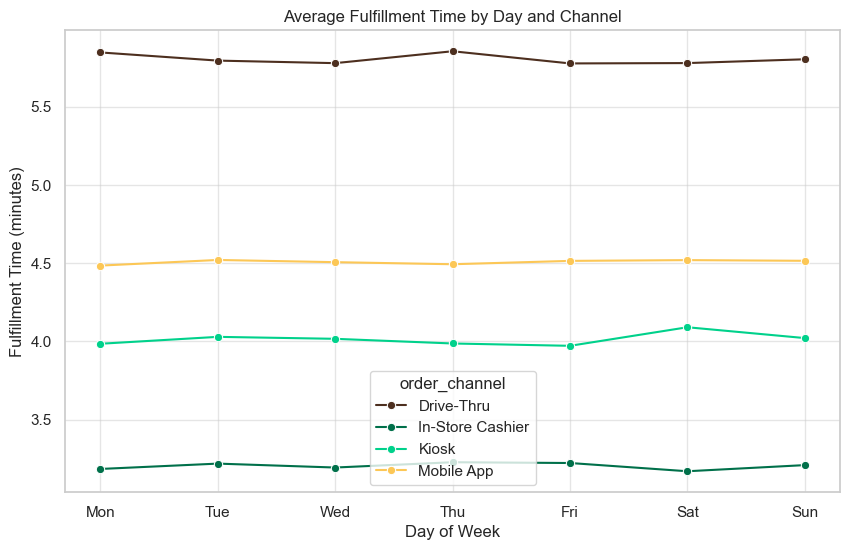

In [20]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fulfillment_trends = df.groupby(['day_of_week', 'order_channel'])['fulfillment_time_min'].mean().reset_index()
fulfillment_trends['day_of_week'] = pd.Categorical(fulfillment_trends['day_of_week'], categories=day_order, ordered=True)
fulfillment_trends = fulfillment_trends.sort_values('day_of_week')

plt.figure(figsize=(10, 6))
sns.lineplot(data=fulfillment_trends, x="day_of_week", y="fulfillment_time_min", hue="order_channel", marker="o", palette=starbucks_palette, sort=False)
plt.title("Average Fulfillment Time by Day and Channel")
plt.xlabel("Day of Week")
plt.ylabel("Fulfillment Time (minutes)")
plt.show()


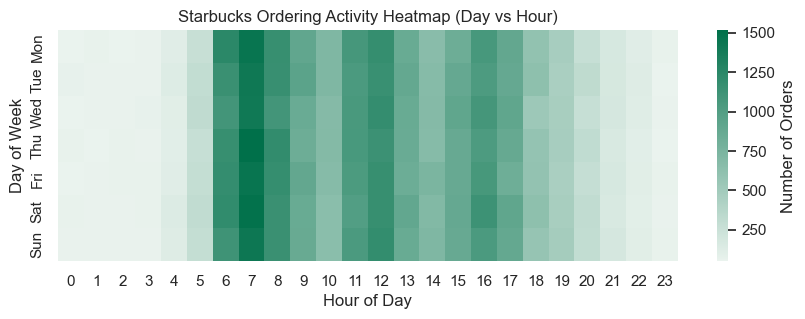

In [21]:
df['order_hour'] = df['order_time'].apply(lambda x: int(x.split(':')[0]))
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data = df.groupby(['day_of_week', 'order_hour']).size().unstack(level='order_hour').reindex(day_order)

plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, cmap=sns.light_palette(COLORS["STARBUCKS_GREEN"], as_cmap=True), cbar_kws={'label': 'Number of Orders'})
plt.title("Starbucks Ordering Activity Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


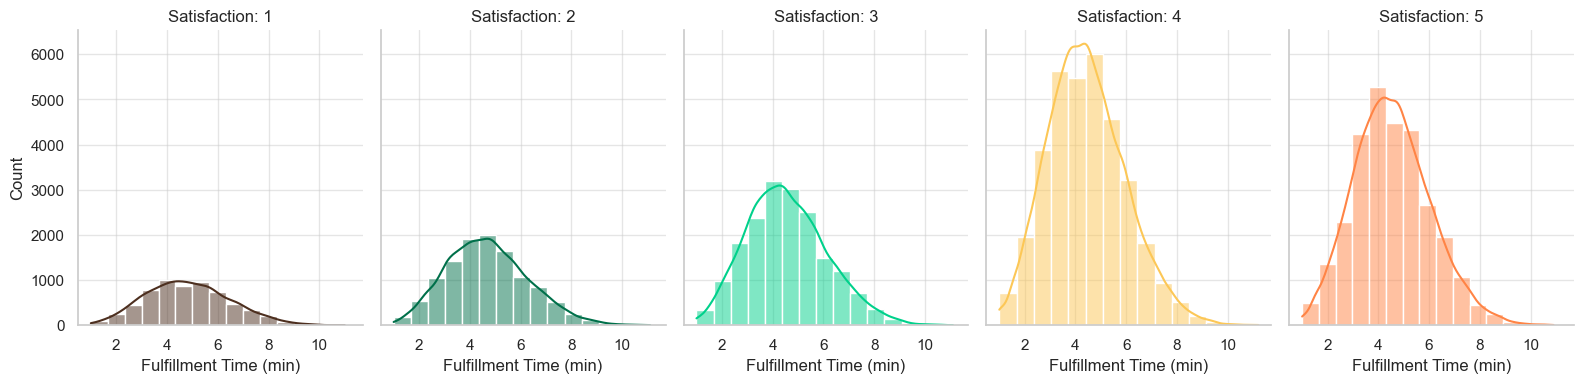

In [22]:
g = sns.FacetGrid(df, col="customer_satisfaction", hue="customer_satisfaction", palette=starbucks_palette, height=4, aspect=0.8)
g.map(sns.histplot, "fulfillment_time_min", kde=True, bins=15)
g.set_titles("Satisfaction: {col_name}")
g.set_axis_labels("Fulfillment Time (min)", "Count")
plt.show()


In [23]:
df['time_of_day'] = pd.cut(df['order_hour'],
                           bins=[-1, 6, 11, 16, 21, 24], 
                           labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Night'], 
                           ordered=False)

df['order_date'] = pd.to_datetime(df['order_date'])
df['season'] = df['order_date'].dt.month.map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

df[['order_date', 'season', 'order_time', 'time_of_day']].head(10)


,order_date,season,order_time,time_of_day
order_id,,,,
ORD_00000001,2024-03-25,Spring,08:47,Morning
ORD_00000002,2025-07-18,Summer,08:02,Morning
ORD_00000003,2025-01-15,Winter,05:40,Night
ORD_00000004,2024-07-30,Summer,15:10,Afternoon
ORD_00000005,2024-06-18,Summer,07:38,Morning
ORD_00000006,2025-08-30,Summer,11:41,Morning
ORD_00000007,2025-10-05,Autumn,06:55,Night
ORD_00000008,2025-12-17,Winter,19:08,Evening
ORD_00000009,2024-02-03,Winter,06:44,Night


/var/folders/vf/__4sd2yj09b6xhtcxvwtxcc40000gn/T/ipykernel_3539/21395878.py:3: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.countplot(ax=axes[0], x='season', hue='drink_category', data=df,
/var/folders/vf/__4sd2yj09b6xhtcxvwtxcc40000gn/T/ipykernel_3539/21395878.py:14: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.countplot(ax=axes[1], x='time_of_day', hue='drink_category', data=df,


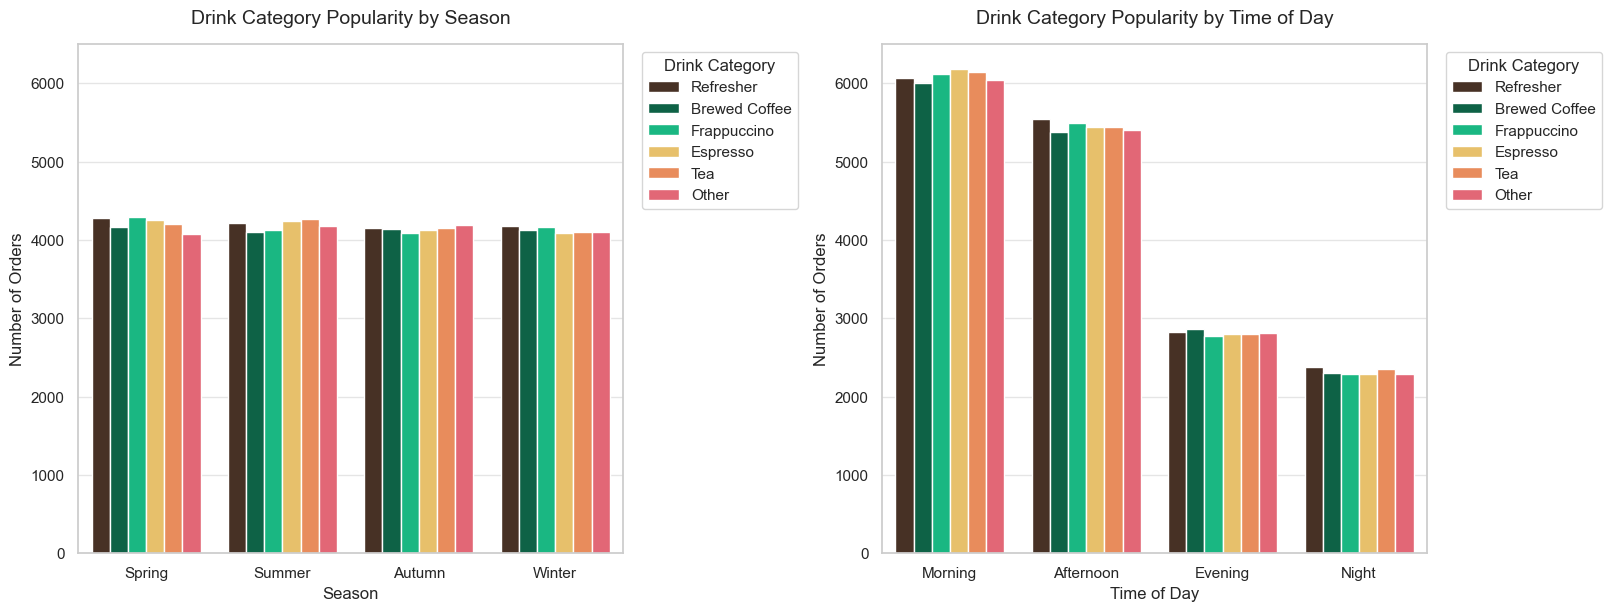

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.countplot(ax=axes[0], x='season', hue='drink_category', data=df,
              order=['Spring', 'Summer', 'Autumn', 'Winter'],
              palette=starbucks_palette)
axes[0].set_title('Drink Category Popularity by Season', fontsize=14, pad=15)
axes[0].set_xlabel('Season', fontsize=12)
axes[0].set_ylabel('Number of Orders', fontsize=12)

axes[0].legend(title='Drink Category', bbox_to_anchor=(1.02, 1), loc='upper left')


time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
sns.countplot(ax=axes[1], x='time_of_day', hue='drink_category', data=df,
              order=time_order, palette=starbucks_palette)
axes[1].set_title('Drink Category Popularity by Time of Day', fontsize=14, pad=15)
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].set_ylabel('Number of Orders', fontsize=12)

axes[1].legend(title='Drink Category', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].set_ylim(0, 6500)
axes[1].set_ylim(0, 6500)


plt.show()


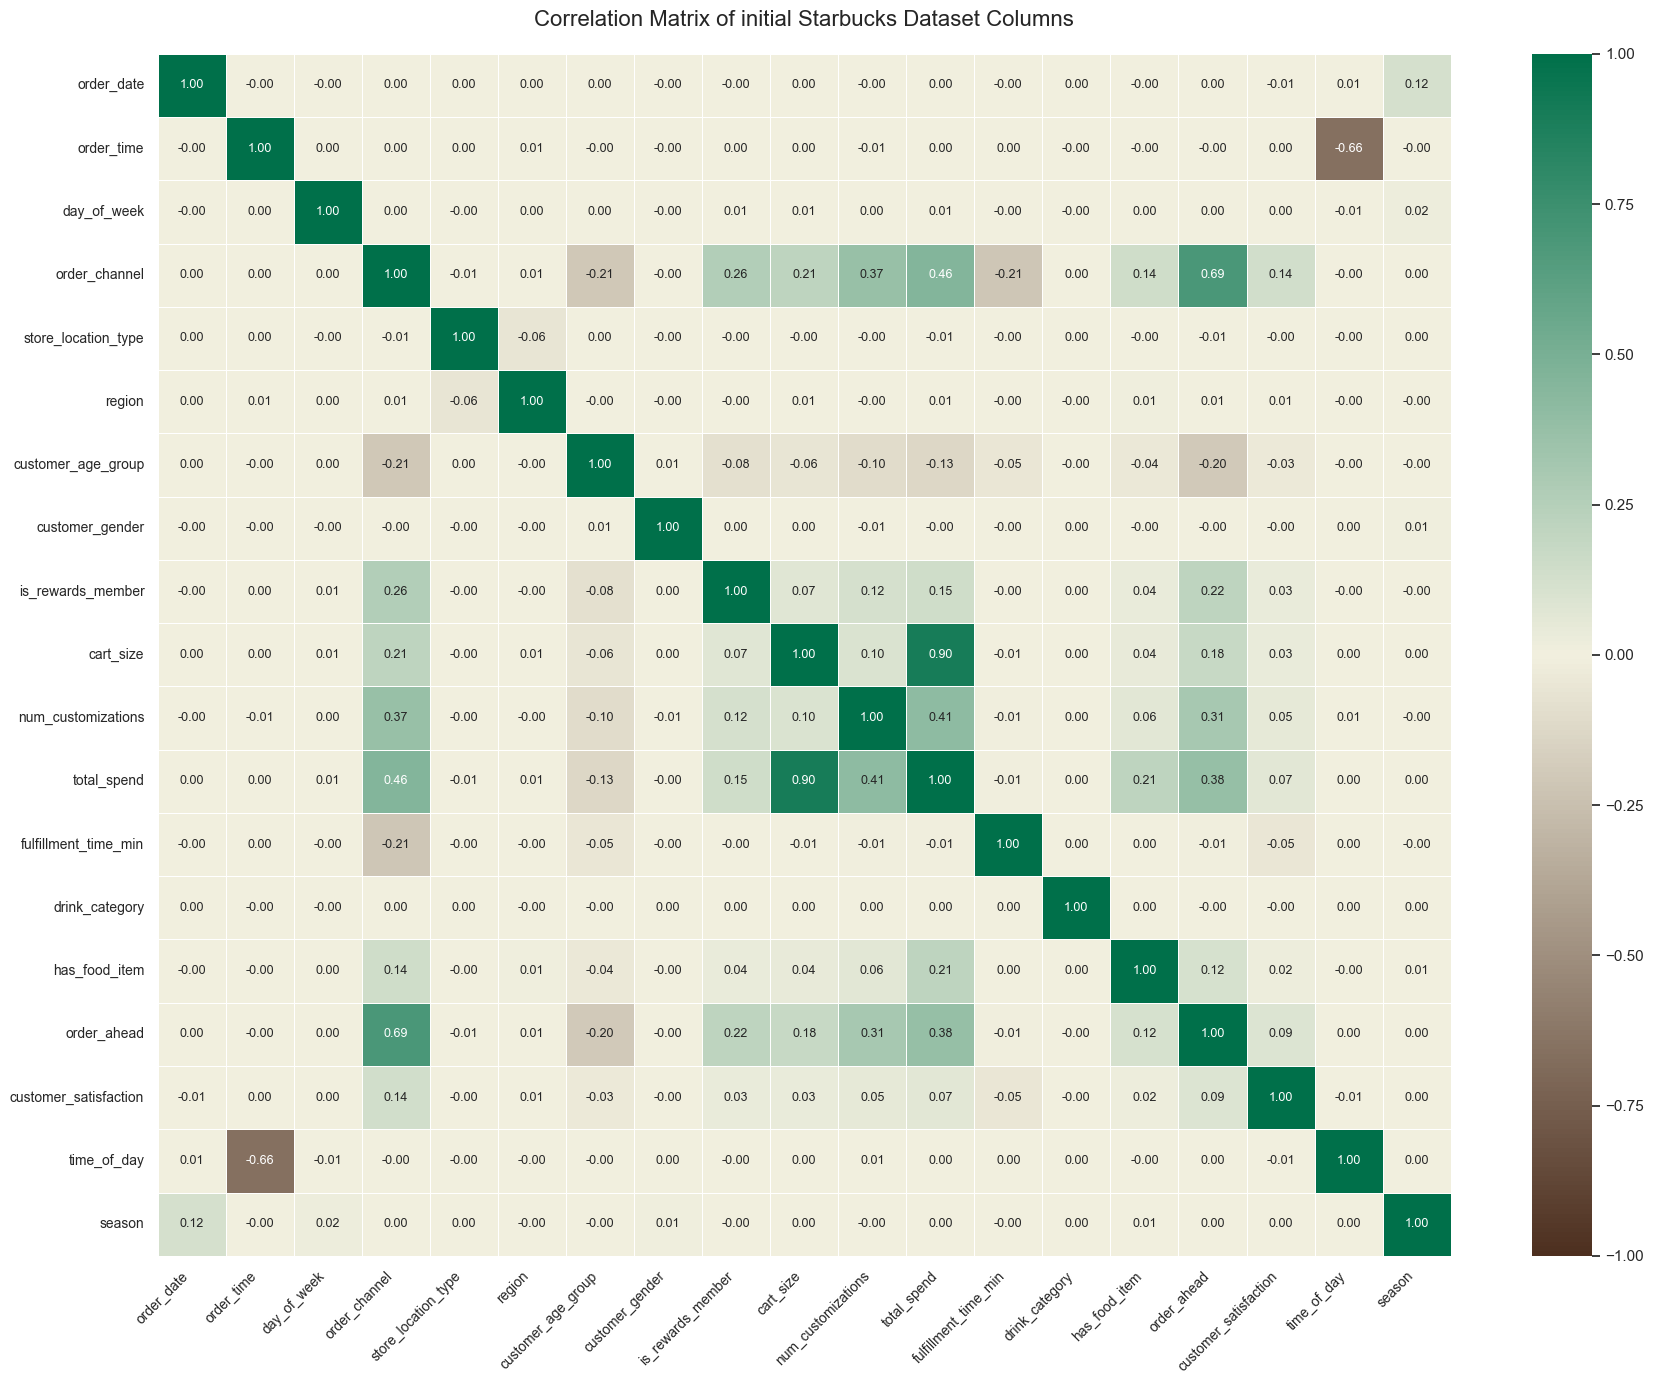

In [25]:
df_all = df.reset_index()

cols = [
    'order_date', 'order_time', 'day_of_week',
    'order_channel', 'store_location_type', 'region',
    'customer_age_group', 'customer_gender', 'is_rewards_member', 
    'cart_size', 'num_customizations', 'total_spend', 'fulfillment_time_min', 
    'drink_category', 'has_food_item', 'order_ahead', 'customer_satisfaction', 'time_of_day', 'season'
]

df_all = df_all[cols].copy()

df_all['order_date'] = df_all['order_date'].astype('int64') // 10**9

df_all['order_time'] = pd.to_datetime(df_all['order_time'], format='%H:%M').dt.hour * 60 + pd.to_datetime(df_all['order_time'], format='%H:%M').dt.minute

weekday_map = {'Mon': 0, 'Tue': 1, 'Wed': 2, 'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6}
df_all['day_of_week'] = df_all['day_of_week'].map(weekday_map)

age_map = {'18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4}
df_all['customer_age_group'] = df_all['customer_age_group'].map(age_map)

time_map = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
df_all['time_of_day'] = df_all['time_of_day'].map(time_map)

season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
df_all['season'] = df_all['season'].map(season_map)


bool_cols = df_all.select_dtypes(include=['bool']).columns
for col in bool_cols:
    df_all[col] = df_all[col].astype(int)

cat_cols = df_all.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df_all[col] = df_all[col].astype('category').cat.codes

corr_all_20 = df_all.corr()

starbucks_cmap = STARBUCKS_CMAP

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_all_20, 
    annot=True, 
    cmap=starbucks_cmap, 
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    annot_kws={"size": 9}
)
plt.title('Correlation Matrix of initial Starbucks Dataset Columns', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


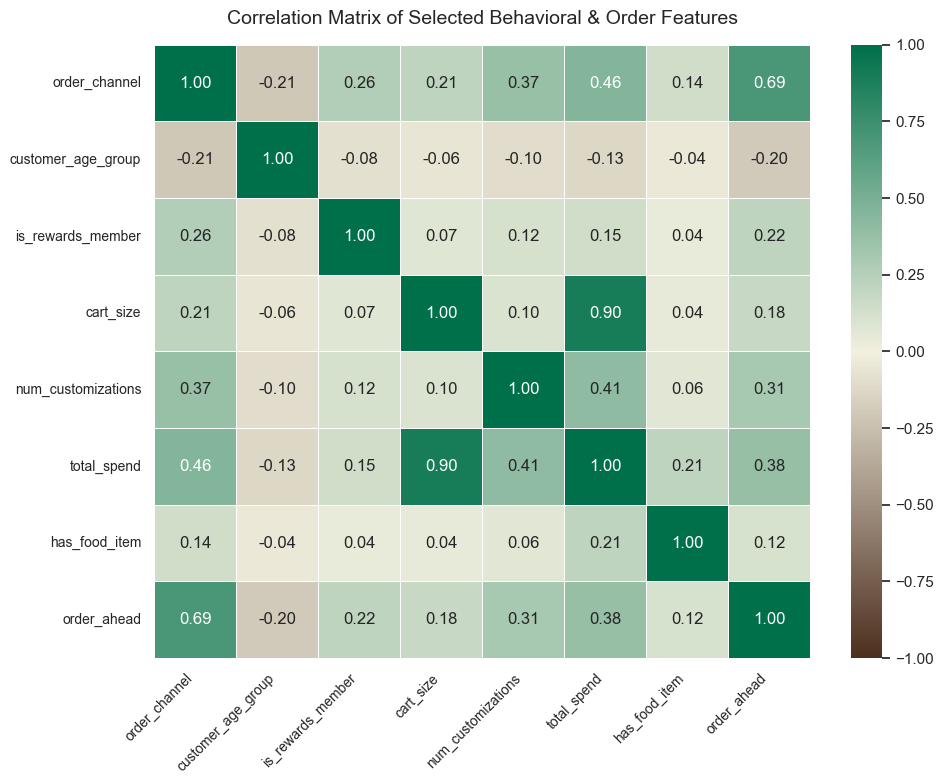

In [26]:
df_selected = df.copy()

age_map = {'18-24': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55+': 4}
df_selected['customer_age_group'] = df_selected['customer_age_group'].map(age_map)

df_selected['order_channel'] = df_selected['order_channel'].astype('category').cat.codes

bool_cols = ['is_rewards_member', 'has_food_item', 'order_ahead']
for col in bool_cols:
    df_selected[col] = df_selected[col].astype(int)

cols = [
    'order_channel', 
    'customer_age_group', 
    'is_rewards_member', 
    'cart_size', 
    'num_customizations', 
    'total_spend', 
    'has_food_item', 
    'order_ahead'
]

corr_selected = df_selected[cols].corr()

small_cmap = STARBUCKS_CMAP

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_selected, 
    annot=True, 
    cmap=small_cmap,
    fmt=".2f", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Correlation Matrix of Selected Behavioral & Order Features', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Nonlinear Waiting Time Threshold ("Boiling Point")

Let's check if customer satisfaction decreases linearly with the increase in waiting time, or if there is a critical waiting threshold after which satisfaction drops sharply. To do this:
1. Group waiting time (`fulfillment_time_min`) into 1-minute intervals and calculate average satisfaction.
2. Plot the graph.
3. Train a decision tree of depth 1 to mathematically find the optimal threshold for separating satisfied and dissatisfied customers.

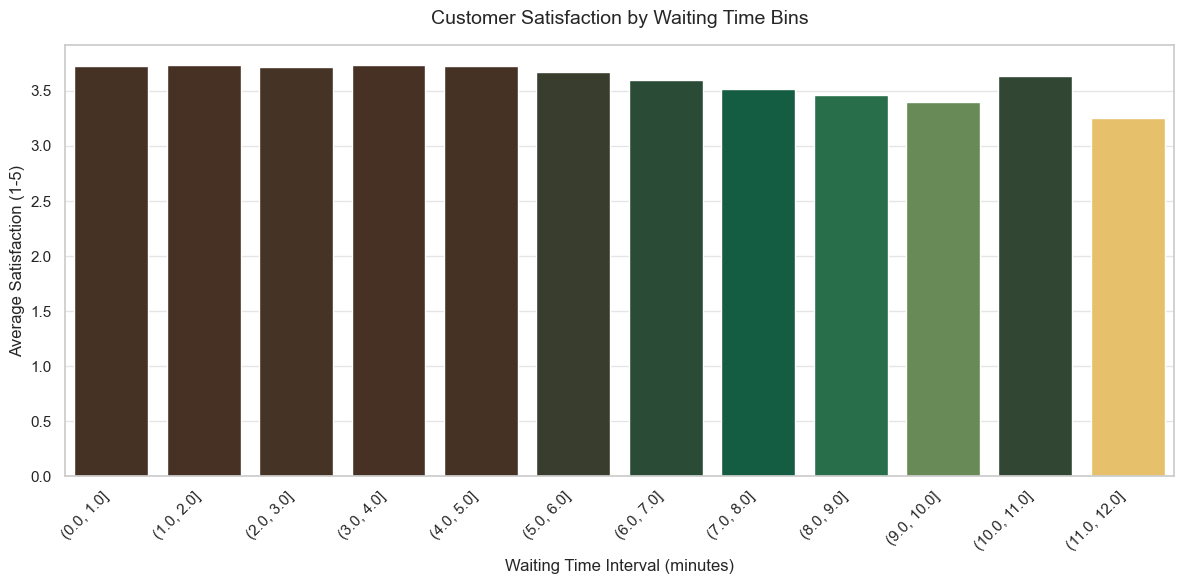

Mathematically determined waiting time threshold: 6.25 minutes
Share of dissatisfied customers when waiting <= 6.25 min: 35.08%
Share of dissatisfied customers when waiting > 6.25 min: 42.04%


In [27]:
bins = np.arange(0, df['fulfillment_time_min'].max() + 1.5, 1)
df['fulfillment_bin'] = pd.cut(df['fulfillment_time_min'], bins=bins)

satisfaction_by_bin = df.groupby('fulfillment_bin', observed=False)['customer_satisfaction'].agg(['mean', 'count']).reset_index()

colors = [COLORS["Y_ACCENT"], COLORS["STARBUCKS_GREEN"], COLORS["COFFEE"]]
cm = LinearSegmentedColormap.from_list("starbucks_grad", colors, N=100)

norm = plt.Normalize(satisfaction_by_bin['mean'].min(), satisfaction_by_bin['mean'].max())
colors_mapped = [cm(norm(val)) for val in satisfaction_by_bin['mean']]

plt.figure(figsize=(12, 6))
sns.barplot(data=satisfaction_by_bin, x='fulfillment_bin', y='mean', palette=colors_mapped, hue='fulfillment_bin', legend=False)
plt.title('Customer Satisfaction by Waiting Time Bins', fontsize=14, pad=15)
plt.xlabel('Waiting Time Interval (minutes)', fontsize=12)
plt.ylabel('Average Satisfaction (1-5)', fontsize=12)
plt.xticks(range(len(satisfaction_by_bin)), satisfaction_by_bin['fulfillment_bin'].unique().tolist(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

df['is_dissatisfied'] = (df['customer_satisfaction'] <= 3).astype(int)

X = df[['fulfillment_time_min']]
y = df['is_dissatisfied']

dt = DecisionTreeClassifier(max_depth=1, random_state=42)
dt.fit(X, y)

threshold = dt.tree_.threshold[0]
print(f"Mathematically determined waiting time threshold: {threshold:.2f} minutes")
print(f"Share of dissatisfied customers when waiting <= {threshold:.2f} min: {df[df['fulfillment_time_min'] <= threshold]['is_dissatisfied'].mean():.2%}")
print(f"Share of dissatisfied customers when waiting > {threshold:.2f} min: {df[df['fulfillment_time_min'] > threshold]['is_dissatisfied'].mean():.2%}")

### Investigation of anomaly in the waiting interval of 10-11 minutes

When analyzing the chart of average satisfaction versus waiting time, a local "spike" in satisfaction can be noticed in the **10-11 minutes** interval (average satisfaction rises to **3.63** compared to **3.40** in the 9-10 minutes interval).

Let's look at this data in details:
1. **Order Channels:** What are the characteristics of orders in this interval?
2. **Sample Size:** Is this spike stat. significant or is it the law of small numbers?
3. **Statistical check (T-test):** Test the hypothesis of equality of average satisfaction values in the 9-10 and 10-11 minutes intervals.

(1) Characteristics of orders in the 10-11 min interval
Number of orders: 60
Sales channels: {'Drive-Thru': 60}
Share of loyalty program members: 31.67%
Average check: $12.68
Average number of customizations: 1.37

(2) Checking the statistical significance of the spike
t-statistic: 1.450
p-value: 0.1506
The difference is NOT statistically significant (p >= 0.05).
The spike is due to high variance because of the small sample size (n = 60) — the effect of the 'law of small numbers'.


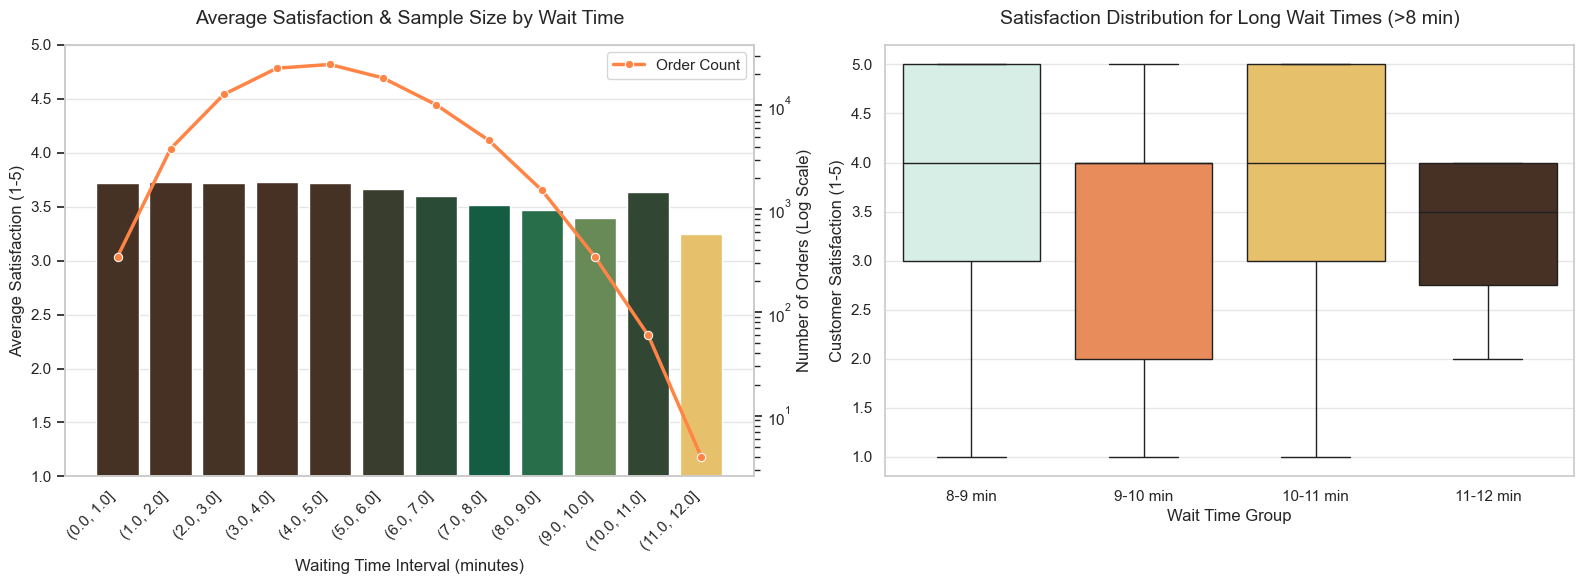

In [28]:
df_10_11 = df[(df['fulfillment_time_min'] > 10) & (df['fulfillment_time_min'] <= 11)]
df_9_10 = df[(df['fulfillment_time_min'] > 9) & (df['fulfillment_time_min'] <= 10)]

print("(1) Characteristics of orders in the 10-11 min interval")
print(f"Number of orders: {len(df_10_11)}")
print(f"Sales channels: {df_10_11['order_channel'].value_counts().to_dict()}")
print(f"Share of loyalty program members: {df_10_11['is_rewards_member'].mean():.2%}")
print(f"Average check: ${df_10_11['total_spend'].mean():.2f}")
print(f"Average number of customizations: {df_10_11['num_customizations'].mean():.2f}")

from scipy import stats
t_stat, p_val = stats.ttest_ind(df_10_11['customer_satisfaction'], df_9_10['customer_satisfaction'], equal_var=False)
print(f"\n(2) Checking the statistical significance of the spike")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")
if p_val < 0.05:
    print("The difference is STATISTICALLY SIGNIFICANT (p < 0.05). The spike is due to real factors.")
else:
    print("The difference is NOT statistically significant (p >= 0.05).")
    print("The spike is due to high variance because of the small sample size (n = 60) — the effect of the 'law of small numbers'.")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

bins = np.arange(0, df['fulfillment_time_min'].max() + 1.5, 1)
df['fulfillment_bin'] = pd.cut(df['fulfillment_time_min'], bins=bins)
satisfaction_by_bin = df.groupby('fulfillment_bin', observed=False)['customer_satisfaction'].agg(['mean', 'count']).reset_index()
satisfaction_by_bin['bin_str'] = satisfaction_by_bin['fulfillment_bin'].astype(str)

colors = [COLORS["Y_ACCENT"], COLORS["STARBUCKS_GREEN"], COLORS["COFFEE"]]
cm = LinearSegmentedColormap.from_list("starbucks_grad", colors, N=100)
norm = plt.Normalize(satisfaction_by_bin['mean'].min(), satisfaction_by_bin['mean'].max())
colors_mapped = [cm(norm(val)) for val in satisfaction_by_bin['mean']]

sns.barplot(data=satisfaction_by_bin, x='bin_str', y='mean', palette=colors_mapped, hue='bin_str', legend=False, ax=ax1)
ax1.set_title("Average Satisfaction & Sample Size by Wait Time", fontsize=14, pad=15)
ax1.set_xlabel("Waiting Time Interval (minutes)", fontsize=12)
ax1.set_ylabel("Average Satisfaction (1-5)", fontsize=12)
ax1.set_ylim(1.0, 5.0)
ax1.set_xticks(range(len(satisfaction_by_bin)))
ax1.set_xticklabels(satisfaction_by_bin['bin_str'], rotation=45, ha='right')

ax1_twin = ax1.twinx()
sns.lineplot(data=satisfaction_by_bin, x=range(len(satisfaction_by_bin)), y='count', color=COLORS["O_ACCENT"], marker='o', linewidth=2.5, label='Order Count', ax=ax1_twin)
ax1_twin.set_ylabel("Number of Orders (Log Scale)", fontsize=12)
ax1_twin.set_yscale('log')
ax1_twin.grid(False)
ax1_twin.legend(loc='upper right')

df_long_wait = df[df['fulfillment_time_min'] > 8].copy()
df_long_wait['wait_group'] = pd.cut(df_long_wait['fulfillment_time_min'], bins=[8, 9, 10, 11, 12], labels=['8-9 min', '9-10 min', '10-11 min', '11-12 min'])

sns.boxplot(data=df_long_wait, x='wait_group', y='customer_satisfaction', palette=[COLORS["MINT"], COLORS["O_ACCENT"], COLORS["Y_ACCENT"], COLORS["COFFEE"]], hue='wait_group', legend=False, ax=ax2)
ax2.set_title("Satisfaction Distribution for Long Wait Times (>8 min)", fontsize=14, pad=15)
ax2.set_xlabel("Wait Time Group", fontsize=12)
ax2.set_ylabel("Customer Satisfaction (1-5)", fontsize=12)

plt.tight_layout()
plt.show()

### Segmentation Insight ("Multidimensional Customer Profile")

To test the hypothesis of stable behavioral customer profiles, we used the **K-Means clustering method**.

Based on elbow analysis (WCSS curve) and business interpretability requirements, a division into **5 segments** was chosen. This allows us not only to separate loyal customers from dissatisfied ones, but also to perform a deep analysis of the highly profitable audience, dividing it into two key business areas: "Bulk Buyers" and "Customization Kings".

**Identified behavioral segments:**
1.  **Fast & Standard:** Customers with simple orders who get served fastest (3.35 min). Most often order via in-store cashier or kiosk and have high satisfaction (4.17).
2.  **Patient & Standard:** Customers with simple orders at the Drive-Thru who are willing to wait their turn (6.37 min) while maintaining loyalty and high satisfaction (4.14).
3.  **Dissatisfied:** Customers with average orders who had a bad experience due to waiting or errors (satisfaction 1.88).
4.  **Bulk Buyers:** Customers making large orders (averaging 6.22 items with a check of 22.41 USD) with a low number of customizations. Primarily order via the mobile app (67.0%).
5.  **Customization Kings:** Premium customers buying fewer items but heavily customizing each drink (averaging 4.05 modifications per order with a check of 17.50 USD). Primarily use the mobile app (77.5%).

/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/uliana/PycharmProjects/JupyterProject/.venv/lib/python

--- Profiles of Starbucks Customer Segments ---


,segment,total_spend,num_customizations,cart_size,fulfillment_time_min,customer_satisfaction
0,Fast & Standard,22.430318,1.935355,6.221822,4.452031,3.917203
1,Patient & Standard,11.848691,1.225664,2.982698,6.367867,4.136839
2,Dissatisfied,12.956019,1.420835,3.303601,4.706681,1.875417
3,Bulk Buyers,17.433991,4.032165,3.640883,4.401902,4.050482
4,Customization Kings,11.347044,1.121201,2.839557,3.350247,4.164098


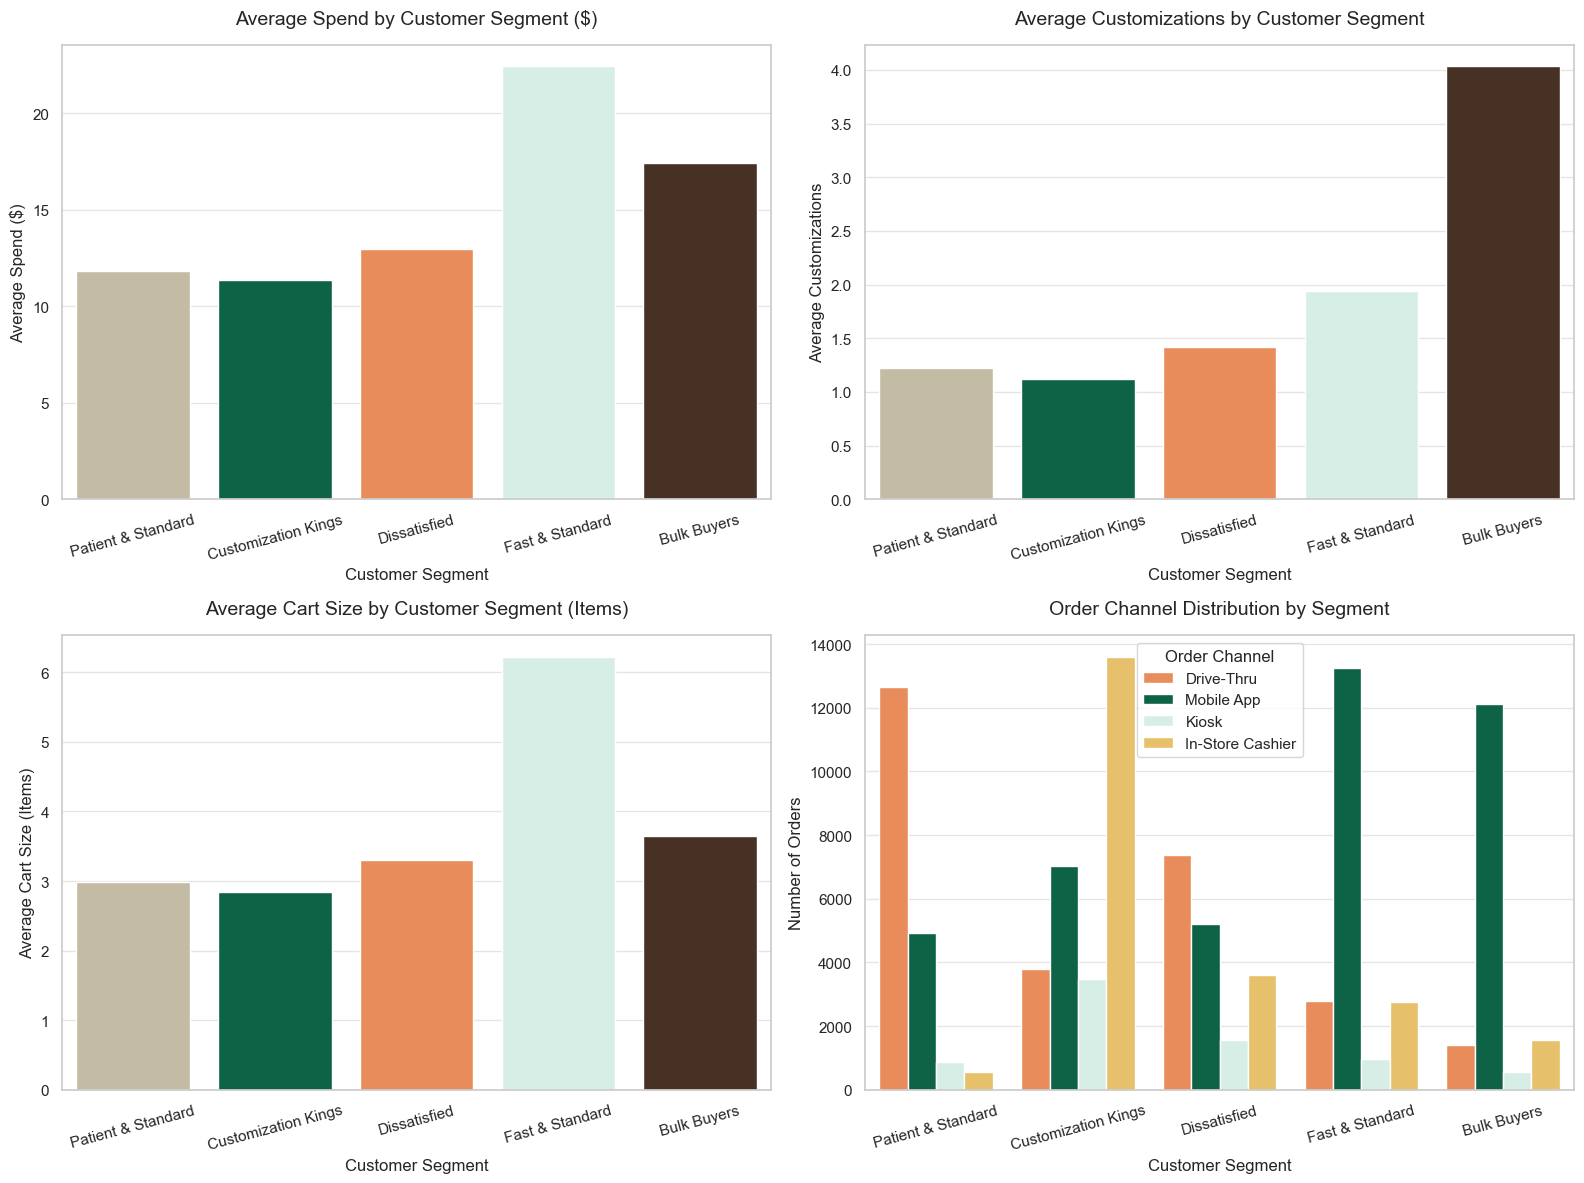

In [29]:
features = ['total_spend', 'num_customizations', 'cart_size', 'fulfillment_time_min', 'customer_satisfaction']
X_cls = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cls)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: "Fast & Standard",
    1: "Patient & Standard",
    2: "Dissatisfied",
    3: "Bulk Buyers",
    4: "Customization Kings"
}
df['segment'] = df['cluster'].map(cluster_names)

cluster_profiles = df.groupby('segment')[features].mean().reindex(
    ["Fast & Standard", "Patient & Standard", "Dissatisfied", "Bulk Buyers", "Customization Kings"]
).reset_index()
print("--- Profiles of Starbucks Customer Segments ---")
display(cluster_profiles)

segment_colors = SEGMENT_COLORS
channel_colors = [COLORS["O_ACCENT"], COLORS["STARBUCKS_GREEN"], COLORS["MINT"], COLORS["Y_ACCENT"]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=df, x='segment', y='total_spend', errorbar=None, palette=segment_colors, hue='segment', legend=False, ax=axes[0,0])
axes[0,0].set_title('Average Spend by Customer Segment ($)', fontsize=14, pad=15)
axes[0,0].set_xlabel('Customer Segment', fontsize=12)
axes[0,0].set_ylabel('Average Spend ($)', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='segment', y='num_customizations', errorbar=None, palette=segment_colors, hue='segment', legend=False, ax=axes[0,1])
axes[0,1].set_title('Average Customizations by Customer Segment', fontsize=14, pad=15)
axes[0,1].set_xlabel('Customer Segment', fontsize=12)
axes[0,1].set_ylabel('Average Customizations', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='segment', y='cart_size', errorbar=None, palette=segment_colors, hue='segment', legend=False, ax=axes[1,0])
axes[1,0].set_title('Average Cart Size by Customer Segment (Items)', fontsize=14, pad=15)
axes[1,0].set_xlabel('Customer Segment', fontsize=12)
axes[1,0].set_ylabel('Average Cart Size (Items)', fontsize=12)
axes[1,0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='segment', hue='order_channel', palette=channel_colors, ax=axes[1,1])
axes[1,1].set_title('Order Channel Distribution by Segment', fontsize=14, pad=15)
axes[1,1].set_xlabel('Customer Segment', fontsize=12)
axes[1,1].set_ylabel('Number of Orders', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(title='Order Channel')

plt.tight_layout()
plt.show()

gender distribution within the Customization Kings segment

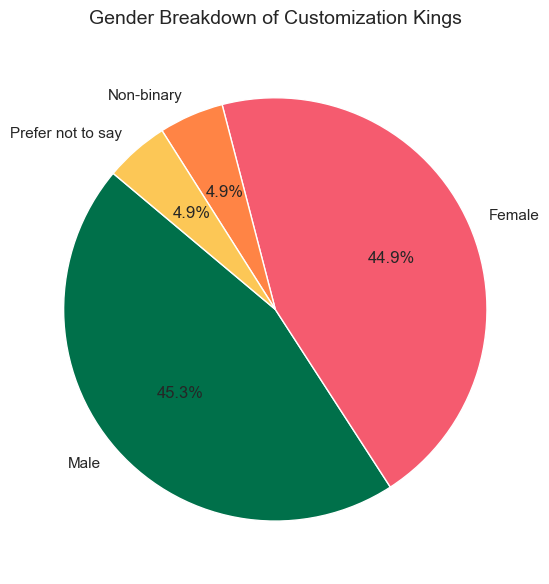

In [32]:
df_kings = df[df['segment'] == 'Customization Kings']
gender_dist = df_kings['customer_gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_dist, 
    labels=gender_dist.index, 
    autopct='%1.1f%%', 
    colors=[COLORS["STARBUCKS_GREEN"], COLORS["ROSE"], COLORS["O_ACCENT"], COLORS["Y_ACCENT"]],
    startangle=140
)
plt.title("Gender Breakdown of Customization Kings", fontsize=14, pad=15)
plt.tight_layout()
plt.show()